# Exploratory Data Analysis & Prediction Framing
**Dataset**: UCI Predict Students' Dropout and Academic Success (ID: 697)

**Objectives**:
1. Ingest dataset programmatically via `ucimlrepo`.
2. Inspect feature attributes, data types, missing values, and target distributions.
3. Establish target simplification strategy.
4. Define the leakage boundary.

## Feature Dictionary & Measurement Context

### Target Variable
* `Target`: Operational outcome (`Graduate`, `Dropout`, `Enrolled`). 

---

### Predictor Variables by Domain

#### 1. Demographic & Socioeconomic Background
* `Marital status`: Categorical code (`1` Single, `2` Married, `3` Widower, `4` Divorced, `5` Facto Union, `6` Legally Separated).
* `Nacionality`: Country of origin code (`1` Portuguese, `109` International codes).
* `Displaced`: Binary (`1` Moved away from hometown for university, `0` Local).
* `Educational special needs`: Binary (`1` Yes, `0` No).
* `Debtor`: Binary (`1` Outstanding tuition debt, `0` No).
* `Tuition fees up to date`: Binary (`1` Yes, `0` No).
* `Gender`: Binary (`1` Male, `0` Female).
* `Scholarship holder`: Binary (`1` Yes, `0` No).
* `Age at enrollment`: Continuous age in years at matriculation.
* `International`: Binary (`1` Yes, `0` No).
* `Mother's/Father's qualification`: Categorical ISCED education level codes (1–44).
* `Mother's/Father's occupation`: Categorical ISCO-08 occupational category codes (0–195).

#### 2. Academic Background & Admission Credentials
* `Application mode`: Categorical admission path ID (1–57).
* `Application order`: Choice preference ranking (0 = 1st choice, up to 9).
* `Course`: Degree program categorical code (33–9991).
* `Daytime/evening attendance`: Binary (`1` Daytime, `0` Evening).
* `Previous qualification`: Categorical level of prior education.
* `Previous qualification (grade)`: Entry grade on the Portuguese national **0 to 200** scale.
* `Admission grade`: University entrance examination grade on the Portuguese national **0 to 200** scale.

#### 3. 1st Semester Performance (Early Warning Window)
* `Curricular units 1st sem (credited)`: Count of transferred course credits.
* `Curricular units 1st sem (enrolled)`: Count of courses registered in Term 1.
* `Curricular units 1st sem (evaluations)`: Total assessment/exam attempts made.
* `Curricular units 1st sem (approved)`: Count of courses passed (grade $\ge 10$).
* `Curricular units 1st sem (grade)`: Average grade point average on the Portuguese **0 to 20 academic scale** (passing grade is 10).
* `Curricular units 1st sem (without evaluations)`: Count of enrolled courses with zero assessment attempts.

#### 4. Excluded Features (Target Leakage Boundary)
* `Curricular units 2nd sem (*)`: All 6 second-semester metrics (`credited`, `enrolled`, `evaluations`, `approved`, `grade`, `without evaluations`). 

#### 5. Macroeconomic Indicators (Enrollment Snapshot)
* `Unemployment rate`: Regional/national unemployment rate (%) at matriculation.
* `Inflation rate`: National inflation rate (%) at matriculation.
* `GDP`: Annual GDP growth rate (%) at matriculation.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Plotting configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [10]:

# Load dataset with semicolon separator
df_raw = pd.read_csv("../data/raw/data.csv", sep=";")

# Display dataset summary information
display(df_raw.head())
display(df_raw.describe())
df_raw.info()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [11]:
# Clean column names (strips trailing tabs like 'Daytime/evening attendance\t')
df_raw.columns = df_raw.columns.str.strip()

# Separate features and target
X_raw = df_raw.drop(columns=["Target"])
y_raw = df_raw[["Target"]]

print(f"Features shape: {X_raw.shape}")
print(f"Target shape:   {y_raw.shape}")

Features shape: (4424, 36)
Target shape:   (4424, 1)


In [12]:
# Verify if any missing values exist across features and target
null_counts = X_raw.isnull().sum()
total_nulls = null_counts.sum()

print(f"Total null values across features: {total_nulls}")
if total_nulls > 0:
    print("\nFeatures with missing values:")
    print(null_counts[null_counts > 0])
else:
    print("Dataset contains 0 null values across all features.")

Total null values across features: 0
Dataset contains 0 null values across all features.


--- Original 3-Class Target Distribution ---
  Target  Count  Percentage (%)
Graduate   2209           49.93
 Dropout   1421           32.12
Enrolled    794           17.95


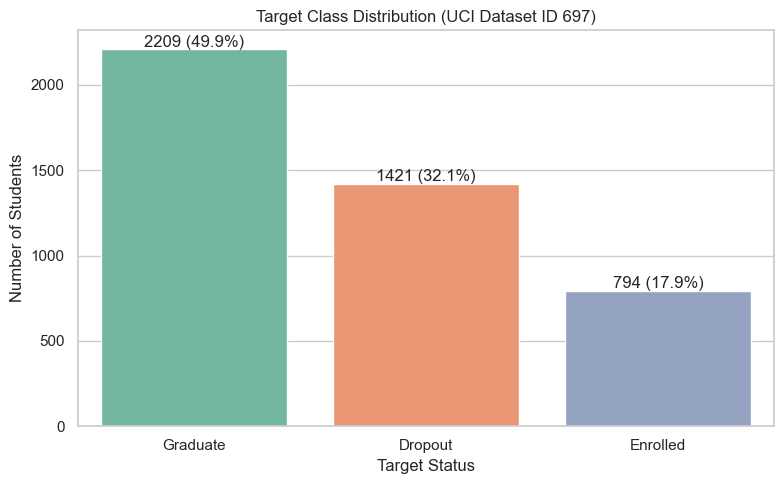

In [14]:
# Analyze 3-class target distribution
target_counts = y_raw["Target"].value_counts()
target_props = y_raw["Target"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Target": target_counts.index,
    "Count": target_counts.values,
    "Percentage (%)": target_props.round(2).values
})

print("--- Original 3-Class Target Distribution ---")
print(target_summary.to_string(index=False))

# Visualize target distribution without warnings
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=target_summary,
    x="Target", 
    y="Count", 
    hue="Target", 
    palette="Set2"
)
plt.title("Target Class Distribution (UCI Dataset ID 697)")
plt.xlabel("Target Status")
plt.ylabel("Number of Students")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)} ({height/len(y_raw)*100:.1f}%)", 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [15]:
# Primary framing: Binary Classification (Dropout = 1, Not-Dropout = 0)
# 'Not-Dropout' aggregates Enrolled + Graduate
y_binary = y_raw["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

binary_summary = pd.DataFrame({
    "Count": y_binary.value_counts(),
    "Percentage (%)": (y_binary.value_counts(normalize=True) * 100).round(2)
}, index=[0, 1])
binary_summary.index = ["Not-Dropout (0)", "Dropout (1)"]

print("--- Binary Target Framing Distribution ---")
print(binary_summary)

--- Binary Target Framing Distribution ---
                 Count  Percentage (%)
Not-Dropout (0)   3003           67.88
Dropout (1)       1421           32.12


In [16]:
# Display all features to identify second-semester variables
all_features = X_raw.columns.tolist()

print(f"Total Features ({len(all_features)}):")
for i, col in enumerate(all_features, 1):
    print(f"{i:02d}. {col}")

Total Features (36):
01. Marital status
02. Application mode
03. Application order
04. Course
05. Daytime/evening attendance
06. Previous qualification
07. Previous qualification (grade)
08. Nacionality
09. Mother's qualification
10. Father's qualification
11. Mother's occupation
12. Father's occupation
13. Admission grade
14. Displaced
15. Educational special needs
16. Debtor
17. Tuition fees up to date
18. Gender
19. Scholarship holder
20. Age at enrollment
21. International
22. Curricular units 1st sem (credited)
23. Curricular units 1st sem (enrolled)
24. Curricular units 1st sem (evaluations)
25. Curricular units 1st sem (approved)
26. Curricular units 1st sem (grade)
27. Curricular units 1st sem (without evaluations)
28. Curricular units 2nd sem (credited)
29. Curricular units 2nd sem (enrolled)
30. Curricular units 2nd sem (evaluations)
31. Curricular units 2nd sem (approved)
32. Curricular units 2nd sem (grade)
33. Curricular units 2nd sem (without evaluations)
34. Unemployment

In [17]:
# Identify second-semester academic features to exclude for early warning
second_sem_features = [col for col in all_features if "2nd sem" in col.lower()]

print("--- Second-Semester Features (To Be Excluded for Early-Warning) ---")
for col in second_sem_features:
    print(f"- {col}")

# Construct Early-Warning feature set (Enrollment info + 1st Semester metrics)
X_early_warning = X_raw.drop(columns=second_sem_features)

print(f"\nFull-Information Feature Count: {X_raw.shape[1]}")
print(f"Early-Warning Feature Count:    {X_early_warning.shape[1]}")

--- Second-Semester Features (To Be Excluded for Early-Warning) ---
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)

Full-Information Feature Count: 36
Early-Warning Feature Count:    30


In [18]:
# Summary statistics for early warning features
X_early_warning.describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
Marital status,1.178571,0.605747,1.00,1.000000,6.000
Application mode,18.669078,17.484682,1.00,17.000000,57.000
Application order,1.727848,1.313793,0.00,1.000000,9.000
Course,8856.642631,2063.566416,33.00,9238.000000,9991.000
Daytime/evening attendance,0.890823,0.311897,0.00,1.000000,1.000
Previous qualification,4.577758,10.216592,1.00,1.000000,43.000
Previous qualification (grade),132.613314,13.188332,95.00,133.100000,190.000
Nacionality,1.873192,6.914514,1.00,1.000000,109.000
Mother's qualification,19.561935,15.603186,1.00,19.000000,44.000
Father's qualification,22.275316,15.343108,1.00,19.000000,44.000


In [19]:
import os

# Ensure output directories exist
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# Combine features with target for local exports
full_df = X_raw.copy()
full_df["target_3class"] = y_raw["Target"]
full_df["target_binary"] = y_binary

early_warning_df = X_early_warning.copy()
early_warning_df["target_3class"] = y_raw["Target"]
early_warning_df["target_binary"] = y_binary

# Export to CSV
full_df.to_csv("../data/processed/student_data_full.csv", index=False)
early_warning_df.to_csv("../data/processed/student_data_early_warning.csv", index=False)

print("Export complete:")
print("- ../data/processed/student_data_full.csv")
print("- ../data/processed/student_data_early_warning.csv")

Export complete:
- ../data/processed/student_data_full.csv
- ../data/processed/student_data_early_warning.csv
